In [1]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn


In [2]:
df = pd.read_csv('diabetes.csv')
print(df.sample(5))
print(df.info())


     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
614           11      138             74             26      144  36.1   
723            5      117             86             30      105  39.1   
376            0       98             82             15       84  25.2   
118            4       97             60             23        0  28.2   
694            2       90             60              0        0  23.5   

     DiabetesPedigreeFunction  Age  Outcome  
614                     0.557   50        1  
723                     0.251   42        0  
376                     0.299   22        0  
118                     0.443   22        0  
694                     0.191   25        0  
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose         

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler



X = df.drop(["Outcome"], axis=1)
y = df["Outcome"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
log_reg = LogisticRegression()
param_grid = {
    'C': [0.1, 0.01, 1, 10, 100,0.001],
    'max_iter': [500, 250, 1000, 1500, 2000]
}
grid_search = GridSearchCV(log_reg, param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)
print(f"Best parameters: {grid_search.best_params_} and {grid_search.best_score_}")
print(f"Best parameters: {grid_search.best_estimator_} and {grid_search.best_score_}")
best_model = grid_search.best_estimator_



Best parameters: {'C': 0.01, 'max_iter': 500} and 0.7687591630014661
Best parameters: LogisticRegression(C=0.01, max_iter=500) and 0.7687591630014661


In [25]:

from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# 1. Build a pipeline: First scale the data, then apply the model
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('log_reg', LogisticRegression())
])

# 2. Define your grid (Notice the 'log_reg__' prefix! This tells the pipeline 
# exactly which step these parameters belong to)
param_grid = {
    'log_reg__C': [0.001, 0.01, 0.1, 1, 10, 100],
    
    # We set a fixed, safe step limit directly in the pipeline, or we can test high values:
    'log_reg__max_iter': [250 ,500, 1000, 2000] 
}

# 3. Set up the Grid Search using the pipeline
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy')

# 4. Run it!
grid_search.fit(X_train, y_train)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best score: {grid_search.best_score_}")
print(f"Best estimator: {grid_search.best_estimator_}")
# 5. Extract and use your best model
best_model = grid_search.best_estimator_


Best parameters: {'log_reg__C': 10, 'log_reg__max_iter': 250}
Best score: 0.7655071304811408
Best estimator: Pipeline(steps=[('scaler', StandardScaler()),
                ('log_reg', LogisticRegression(C=10, max_iter=250))])


In [6]:
model = LogisticRegression(C=15, max_iter=20000)  # smaller C = stronger regularization
model.fit(X_train, y_train)


y_pred = model.predict(X_test)

In [7]:
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Cross Validation
scores = cross_val_score(model, X, y, cv=5, scoring="accuracy")
print("\nCross-validation scores:", scores)
print("Mean accuracy:", scores.mean())

Accuracy: 0.7532

Confusion Matrix:
[[79 20]
 [18 37]]

Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.80      0.81        99
           1       0.65      0.67      0.66        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154




Cross-validation scores: [0.77272727 0.74675325 0.75324675 0.81699346 0.76470588]
Mean accuracy: 0.7708853238265002


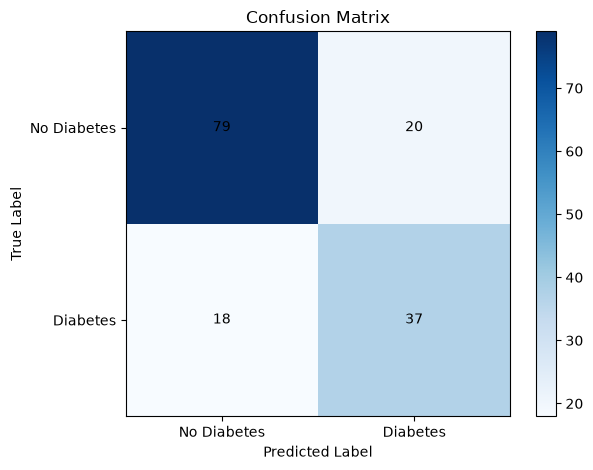

In [8]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

# Define your class labels (change according to your problem)
labels = ["No Diabetes", "Diabetes"]   # e.g. ["Cat", "Dog"]

plt.figure()
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

# Add ticks and labels
plt.xticks(ticks=np.arange(len(labels)), labels=labels)
plt.yticks(ticks=np.arange(len(labels)), labels=labels)

# Add numbers inside cells
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j],
                 ha="center", va="center", color="black")

plt.tight_layout()
plt.show()

In [9]:
df.sample()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
544,1,88,78,29,76,32.0,0.365,29,0


In [10]:
data=[[0, 100, 115, 35, 0, 29.1, 0.221, 30]]
prediction = model.predict(data)
print("Prediction for data ",prediction)

Prediction for data  [0]


/Users/macbookair/Desktop/ML/VE/lib/python3.14/site-packages/sklearn/utils/validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [11]:
import pickle
# Save the model to disk
with open('diabetes_model.pkl', 'wb') as file:
    pickle.dump(model, file)
